<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [ ]:
#!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

In [1]:
!curl -o survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  152M  100  152M    0     0  48.0M      0  0:00:03  0:00:03 --:--:-- 48.0M


#### Install the required libraries and import them


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


In [10]:
# Read the CSV file first in pandas
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [11]:
# Get description of your column

df['CompTotal'].describe()

count     3.374000e+04
mean     2.963841e+145
std      5.444117e+147
min       0.000000e+00
25%       6.000000e+04
50%       1.100000e+05
75%       2.500000e+05
max      1.000000e+150
Name: CompTotal, dtype: float64

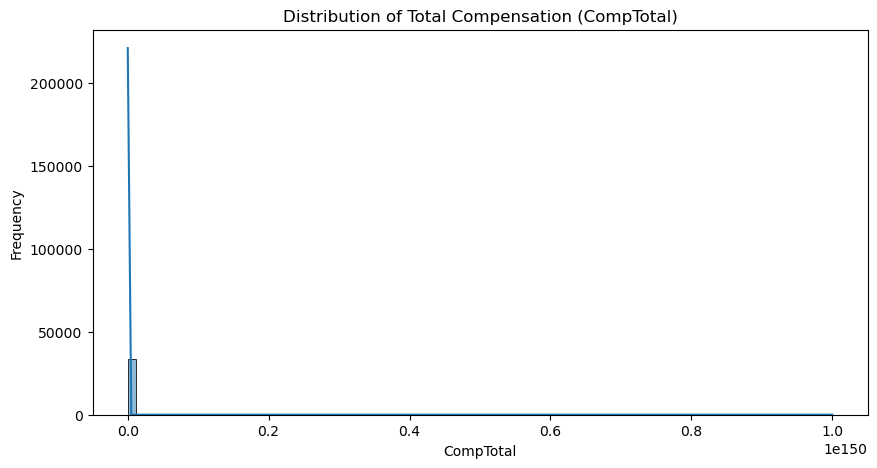

In [12]:
# Histogram of CompTotal (Total Compensation)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(df['CompTotal'], bins=90, kde=True)

plt.title('Distribution of Total Compensation (CompTotal)')
plt.xlabel('CompTotal')
plt.ylabel('Frequency')

plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [14]:
# First, inspect the column df['YearsCodePro']

print("YearsCodePro — Missing values:\n", df['YearsCodePro'].isna().sum())
print()
print("YearsCodePro — Describe:\n", df['YearsCodePro'].describe())
print()
print("YearsCodePro — Value counts (top 10):\n", df['YearsCodePro'].value_counts(dropna=False).head(10))

YearsCodePro — Missing values:
 13827

YearsCodePro — Describe:
 count     51610
unique       52
top           2
freq       4168
Name: YearsCodePro, dtype: object

YearsCodePro — Value counts (top 10):
 NaN                 13827
2                    4168
3                    4093
5                    3526
10                   3251
4                    3215
Less than 1 year     2856
6                    2843
1                    2639
8                    2549
Name: YearsCodePro, dtype: int64


In [15]:
# Transform this column to float type

def convert_experience(x):
    if x == "Less than 1 year":
        return 0.5
    elif x == "More than 50 years":
        return 50
    else:
        return float(x)

df['YearsCodePro_num'] = df['YearsCodePro'].apply(convert_experience)

In [16]:
## Check transformation

cols = ['YearsCodePro', 'YearsCodePro_num']

for c in cols:
    if c in df.columns:
        print(f"\n{c} — Missing values:", df[c].isna().sum())
        print(f"{c} — Describe:\n", df[c].describe())
        print(f"{c} — Value counts (top 10):\n", df[c].value_counts(dropna=False).head(10))


YearsCodePro — Missing values: 13827
YearsCodePro — Describe:
 count     51610
unique       52
top           2
freq       4168
Name: YearsCodePro, dtype: object
YearsCodePro — Value counts (top 10):
 NaN                 13827
2                    4168
3                    4093
5                    3526
10                   3251
4                    3215
Less than 1 year     2856
6                    2843
1                    2639
8                    2549
Name: YearsCodePro, dtype: int64

YearsCodePro_num — Missing values: 13827
YearsCodePro_num — Describe:
 count    51610.000000
mean        10.211044
std          9.075136
min          0.500000
25%          3.000000
50%          7.000000
75%         15.000000
max         50.000000
Name: YearsCodePro_num, dtype: float64
YearsCodePro_num — Value counts (top 10):
 NaN     13827
2.0      4168
3.0      4093
5.0      3526
10.0     3251
4.0      3215
0.5      2856
6.0      2843
1.0      2639
8.0      2549
Name: YearsCodePro_num, dtype: int64

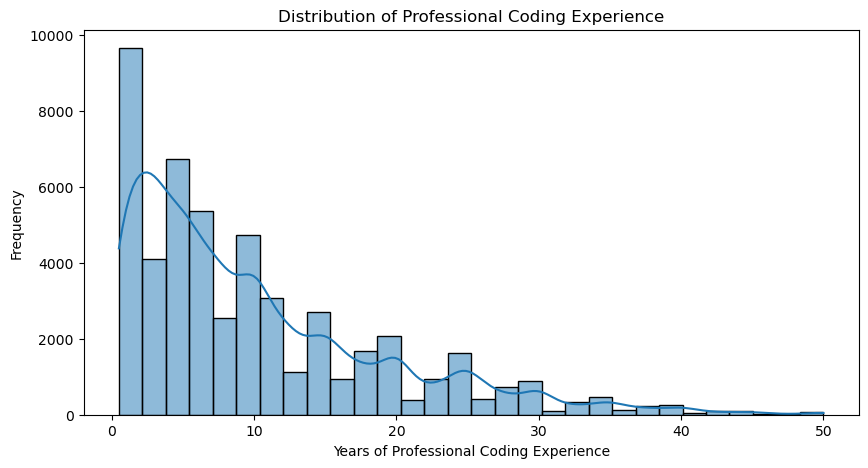

In [18]:
# Histrogram using the transform column 'YearsCodePro_num'

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(df['YearsCodePro_num'].dropna(), bins=30, kde=True)

plt.title('Distribution of Professional Coding Experience')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Frequency')

plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


In [29]:
## Use clean data

df_comp = df[['CompTotal', 'Age']].dropna()

Q1 = df_comp['CompTotal'].quantile(0.25)
Q3 = df_comp['CompTotal'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df_comp[
    (df_comp['CompTotal'] >= lower) &
    (df_comp['CompTotal'] <= upper)
]

df_clean.describe(include="all")

,CompTotal,Age
count,27864.000000,27864
unique,NaN,8
top,NaN,25-34 years old
freq,NaN,11754
mean,117182.605369,NaN
std,99970.300622,NaN
min,0.000000,NaN
25%,50000.000000,NaN
50%,88000.000000,NaN
75%,150000.000000,NaN


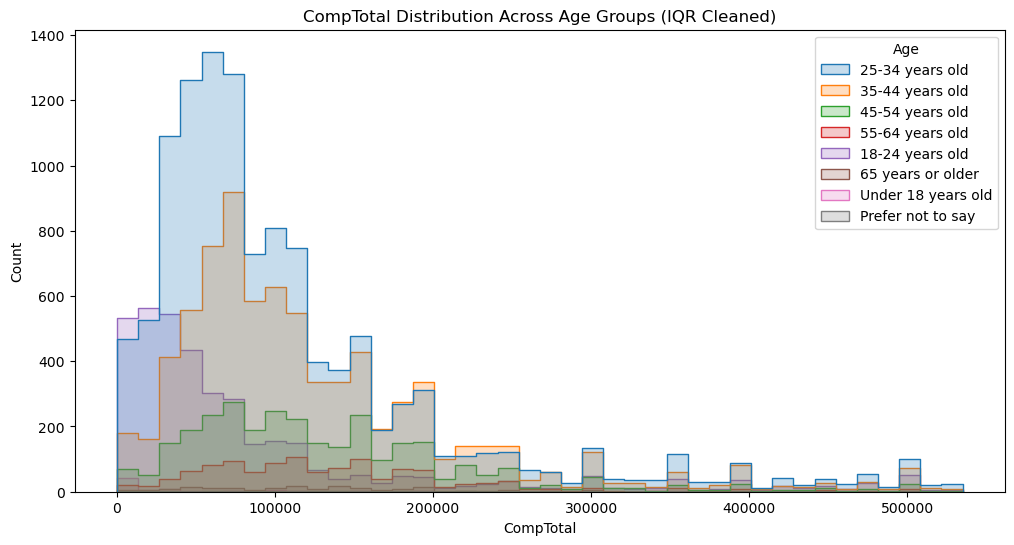

In [32]:
# Histogram of CompTotal Distribution Across Age Groups (IQR Cleaned)

plt.figure(figsize=(12,6))

sns.histplot(
    data=df_clean,
    x='CompTotal',
    hue='Age',
    bins=40,
    element='step',
    common_norm=False
)

plt.title('CompTotal Distribution Across Age Groups (IQR Cleaned)')
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [33]:
## Inspection of variables

print("Missing TimeSearching:", df['TimeSearching'].isna().sum())
print()
print("\nTimeSearching distribution:\n", df['TimeSearching'].value_counts(dropna=False))
print()
print("\nAge distribution:\n", df['Age'].value_counts(dropna=False))

Missing TimeSearching: 36526


TimeSearching distribution:
 NaN                           36526
30-60 minutes a day           10951
15-30 minutes a day            7805
60-120 minutes a day           5275
Less than 15 minutes a day     2689
Over 120 minutes a day         2191
Name: TimeSearching, dtype: int64


Age distribution:
 25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: Age, dtype: int64


In [34]:
# Cleaning dataset

df_ts = df[['TimeSearching', 'Age']].dropna()
df_ts.shape

(28911, 2)

In [35]:
# Transforming data TimeSearching

time_map = {
    'Less than 15 minutes a day': 10,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    'Over 120 minutes a day': 150
}

df_ts['TimeSearching_num'] = df_ts['TimeSearching'].map(time_map)

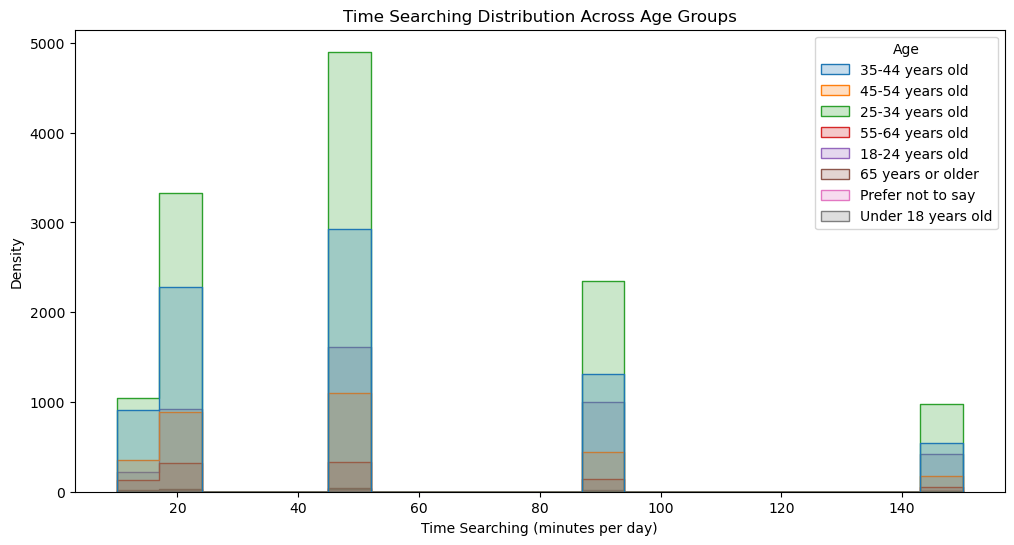

In [36]:
# Histogram of Time Searching Distribution Across Age Groups

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.histplot(
    data=df_ts,
    x='TimeSearching_num',
    hue='Age',
    bins=20,
    element='step',
    common_norm=False
)

plt.title('Time Searching Distribution Across Age Groups')
plt.xlabel('Time Searching (minutes per day)')
plt.ylabel('Density')

plt.show()

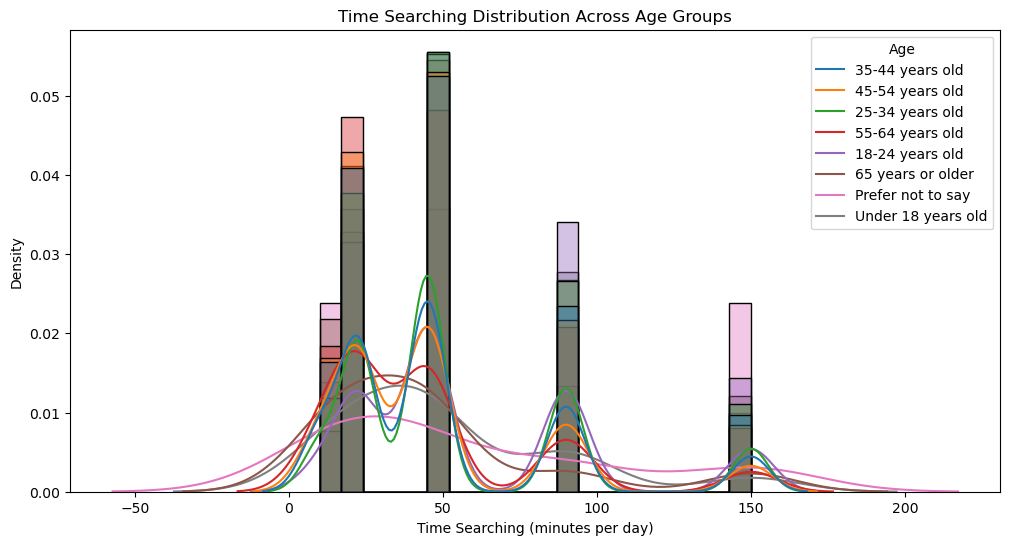

In [37]:
# Histogram + KDE smoothing of Time Searching Distribution Across Age Groups

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.histplot(
    data=df_ts,
    x='TimeSearching_num',
    hue='Age',
    bins=20,
    stat='density',
    common_norm=False,
    alpha=0.4
)

sns.kdeplot(
    data=df_ts,
    x='TimeSearching_num',
    hue='Age',
    common_norm=False
)

plt.title('Time Searching Distribution Across Age Groups')
plt.xlabel('Time Searching (minutes per day)')
plt.ylabel('Density')

plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


In [39]:
# Inspection of variable categories and distribution

print("Database wants distribution:", df['DatabaseWantToWorkWith'].value_counts(dropna=False))
print()
print("Missing values:", df['DatabaseWantToWorkWith'].isna().sum())

Database wants distribution: NaN                                                                                                                                                                22879
PostgreSQL                                                                                                                                                          3738
PostgreSQL;SQLite                                                                                                                                                   1533
SQLite                                                                                                                                                              1476
Microsoft SQL Server                                                                                                                                                1431
                                                                                                                              

In [40]:
# Clean and explode and handle missing values in the variable DATABASE WANTS

db_series = (
    df['DatabaseWantToWorkWith']
    .fillna('None')
    .str.split(';')
    .explode()
    .str.strip()
)

db_series = db_series[db_series != 'None']

print(db_series.describe())

count         127439
unique            35
top       PostgreSQL
freq           24005
Name: DatabaseWantToWorkWith, dtype: object


In [41]:
# Top 5 databases 

top_db = db_series.value_counts().head(5)

print(top_db)

PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: DatabaseWantToWorkWith, dtype: int64


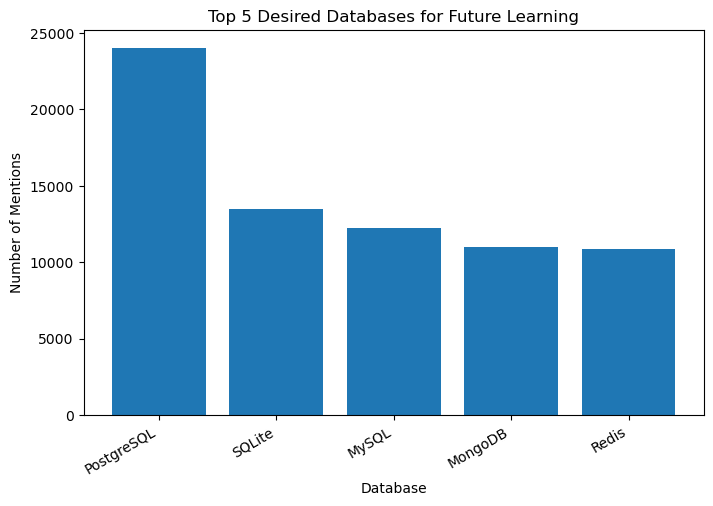

In [42]:
# histogram (categorical distribution), so we use a bar-style histogram.

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(top_db.index, top_db.values)

plt.title('Top 5 Desired Databases for Future Learning')
plt.xlabel('Database')
plt.ylabel('Number of Mentions')

plt.xticks(rotation=30, ha='right')

plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


In [44]:
## Inspection of RemoteWork

col = df['RemoteWork']

print("Missing values:", col.isna().sum())
print("\nDescribe:\n", col.describe())
print("\nValue counts:\n", col.value_counts(dropna=False))

Missing values: 10631

Describe:
 count                                    54806
unique                                       3
top       Hybrid (some remote, some in-person)
freq                                     23015
Name: RemoteWork, dtype: object

Value counts:
 Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
NaN                                     10631
Name: RemoteWork, dtype: int64


In [45]:
# preprocessing

rw = df['RemoteWork'].fillna('Not Specified')

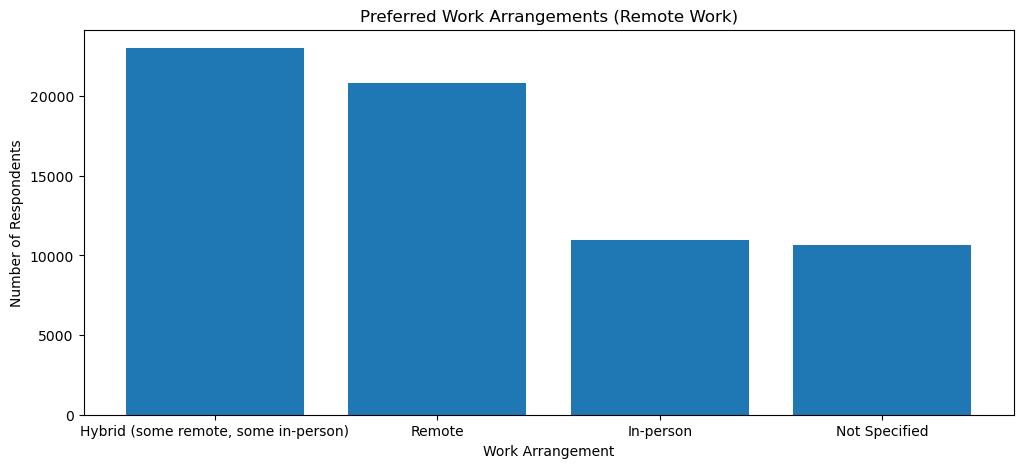

In [49]:
# Histogram of frequecy for categorical variables

import matplotlib.pyplot as plt

counts = rw.value_counts()

plt.figure(figsize=(12,5))

plt.bar(counts.index, counts.values)

plt.title('Preferred Work Arrangements (Remote Work)')
plt.xlabel('Work Arrangement')
plt.ylabel('Number of Respondents')

plt.xticks(rotation=0, ha='center')

plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


In [51]:
# Transforming Age as Age_num

age_map = {
    'Under 18 years old': 17.0,
    '18-24 years old': 21.0,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70.0
}

df['Age_num'] = df['Age'].map(age_map)

In [52]:
## Inspecting Age_num, and filtering age range df_45_60

df_45_60 = df[(df['Age_num'] >= 45) & (df['Age_num'] <= 60)]

print("Missing CompTotal:", df_45_60['CompTotal'].isna().sum())
print("\nCompTotal summary:\n", df_45_60['CompTotal'].describe())

print("\nAge distribution in subset:\n", df_45_60['Age'].value_counts())

Missing CompTotal: 4029

CompTotal summary:
 count    4.795000e+03
mean     2.085506e+49
std      1.444128e+51
min      0.000000e+00
25%      8.000000e+04
50%      1.310000e+05
75%      2.150000e+05
max      1.000000e+53
Name: CompTotal, dtype: float64

Age distribution in subset:
 45-54 years old    6249
55-64 years old    2575
Name: Age, dtype: int64


In [53]:
# dropping nas - preprocessing

df_mid = df_45_60[['CompTotal', 'Age']].dropna()

In [55]:
# removing outliers

df_mid = df[(df['Age_num'] >= 45) & (df['Age_num'] <= 60)][['CompTotal']].dropna()

Q1 = df_mid['CompTotal'].quantile(0.25)
Q3 = df_mid['CompTotal'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_mid_clean = df_mid[
    (df_mid['CompTotal'] >= lower) &
    (df_mid['CompTotal'] <= upper)
]

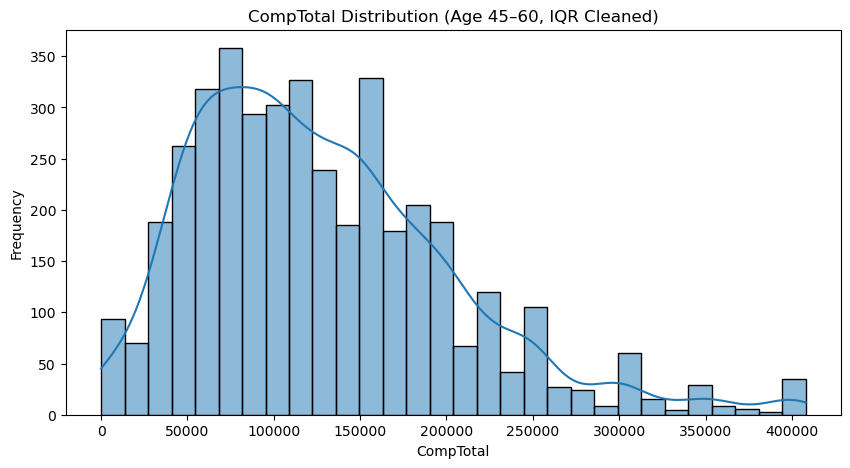

In [56]:
# plot CompTotal Distribution (Age 45–60, IQR Cleaned)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(
    df_mid_clean['CompTotal'],
    bins=30,
 kde=True
)

plt.title('CompTotal Distribution (Age 45–60, IQR Cleaned)')
plt.xlabel('CompTotal')
plt.ylabel('Frequency')

plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


In [57]:
# Inspect columns first

cols = ['JobSat', 'YearsCodePro', 'YearsCodePro_num']

for c in cols:
    if c in df.columns:
        print(f"\n{c} — Missing:", df[c].isna().sum())
        print(df[c].describe())
        print(df[c].value_counts(dropna=False).head(10))


JobSat — Missing: 36311
count    29126.000000
mean         6.935041
std          2.088259
min          0.000000
25%          6.000000
50%          7.000000
75%          8.000000
max         10.000000
Name: JobSat, dtype: float64
NaN     36311
8.0      7509
7.0      6379
6.0      3751
9.0      3626
10.0     2251
5.0      1956
3.0      1165
4.0      1130
2.0       772
Name: JobSat, dtype: int64

YearsCodePro — Missing: 13827
count     51610
unique       52
top           2
freq       4168
Name: YearsCodePro, dtype: object
NaN                 13827
2                    4168
3                    4093
5                    3526
10                   3251
4                    3215
Less than 1 year     2856
6                    2843
1                    2639
8                    2549
Name: YearsCodePro, dtype: int64

YearsCodePro_num — Missing: 13827
count    51610.000000
mean        10.211044
std          9.075136
min          0.500000
25%          3.000000
50%          7.000000
75%         15

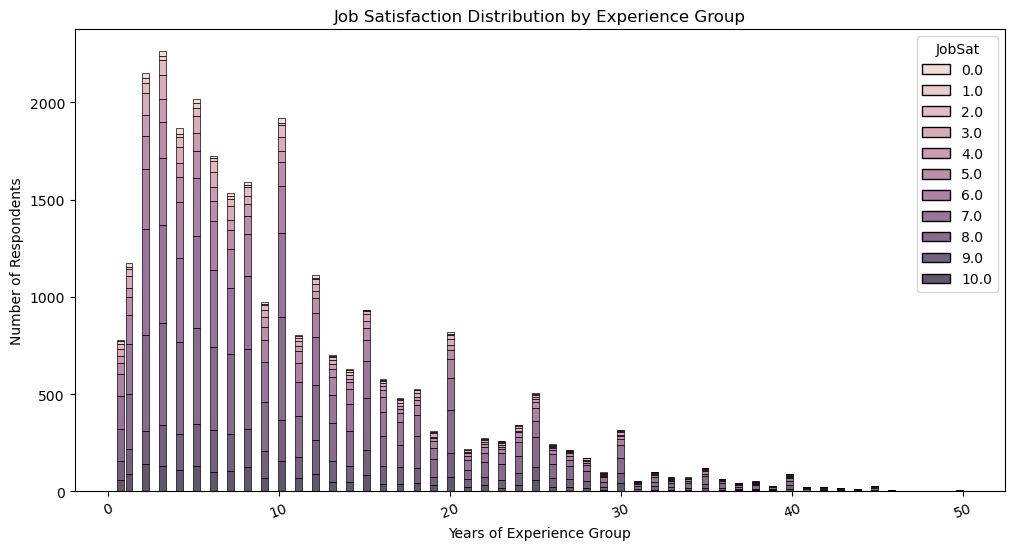

In [68]:


import matplotlib.pyplot as plt
import seaborn as sns

df_js = df[['JobSat', 'YearsCodePro_num']].dropna()

#df_js['ExpGroup'] = pd.cut(
#    df_js['YearsCodePro_num'],
#    bins=[0, 1, 3, 5, 10, 20, 50],
#    labels=['<1', '1–3', '3–5', '5–10', '10–20', '20+']
#)

plt.figure(figsize=(12,6))

sns.histplot(
    data=df_js,
    x='YearsCodePro_num',          # 🔥 switched to categories
    bins=100,
    hue='JobSat',          # numeric distribution inside each group
    multiple='stack',      # makes it readable
    shrink=0.8
)

plt.title('Job Satisfaction Distribution by Experience Group')
plt.xlabel('Years of Experience Group')
plt.ylabel('Number of Respondents')

plt.xticks(rotation=20)

plt.show()

In [85]:
# drop na's

df_js = df[['JobSat', 'YearsCodePro_num']].dropna()
df_js.shape

(28356, 2)

In [86]:
# Adjust bins

df_js['ExpGroup'] = pd.cut(
    df_js['YearsCodePro_num'],
    bins=[0, 1, 3, 5, 10, 20, 50],
    labels=['<1', '1–3', '3–5', '5–10', '10–20', '20+']
)

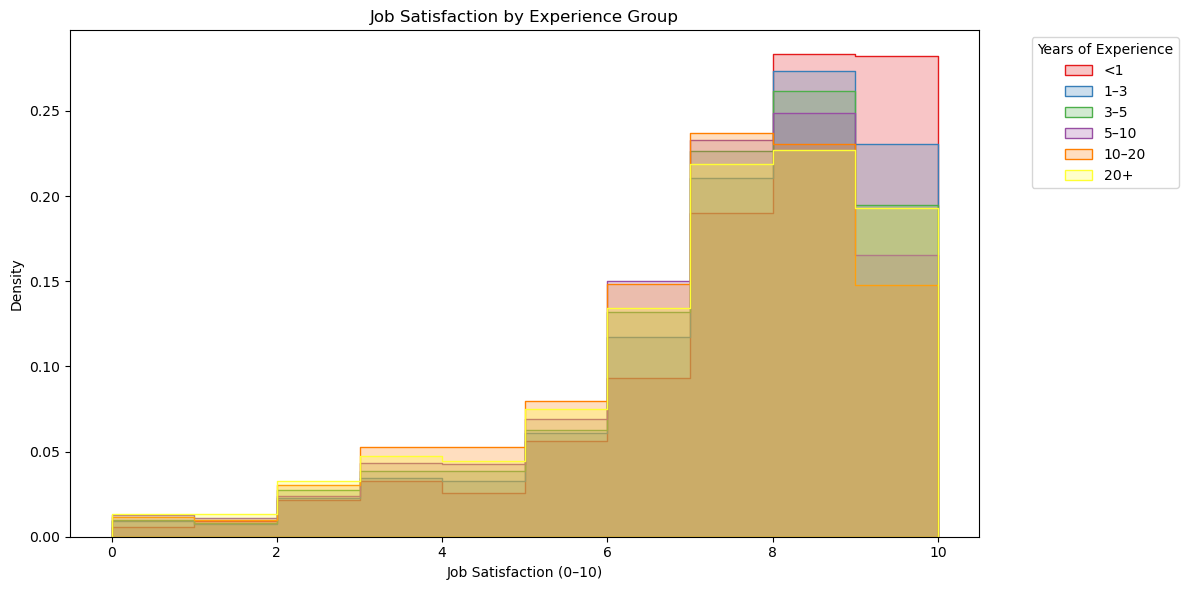

In [87]:


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

ax = sns.histplot(
    data=df_js,
    x='JobSat',
    hue='ExpGroup',
    bins=10,
    element='step',
    stat='density',
    common_norm=False,
#    palette=sns.color_palette("colorblind", n_colors=len(df_js['ExpGroup'].cat.categories))
    palette=sns.color_palette("Set1", n_colors=len(df_js['ExpGroup'].cat.categories))[::-1]
)

plt.title('Job Satisfaction by Experience Group')
plt.xlabel('Job Satisfaction (0–10)')
plt.ylabel('Density')

# 🔥 move legend outside plot
plt.legend(
    title='Years of Experience',
    labels=df_js['ExpGroup'].cat.categories,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [88]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
